# [ML] Twiddler Rule 1·2 재설계 비교 — 2026-07-08

**배경**: 이 프로젝트가 다시 세운 연구 질문은 다음 세 가지다.

1. **해석가능성** — 해석 불가능한 임베딩 대신 자연어 기반 행동 페르소나로 유동적인 소비 선호도를 포착할 수 있는가?
2. **가치관 반영** — 단순 구매확률이 아니라 장기적 소비 가치관·탐색 맥락을 반영해 카테고리 라벨링의 정보력 부족을 해소할 수 있는가?
3. **추천 결합 효과** — 페르소나가 기존 추천 알고리즘과 결합될 때 탐색 비용을 줄이고 '디깅' 경험을 개선하는가?

지난 진단에서 드러난 문제:
- `data/processed/segment_personas_train_only.json`의 `description`/`evidence`는 카테고리 비중·조회수 같은 **정량 통계를 문장으로 서술**한 것이고, 실제 재랭킹(Rule 1)에는 이 자연어 텍스트가 전혀 입력되지 않는다 — 알고리즘은 여전히 "카테고리 비중"만 사용한다.
- Rule 1의 affinity/alpha가 **세그먼트 평균**으로 뭉개져 있어(6개 이산 버킷) 같은 세그먼트 유저는 전부 동일한 배율을 받는다 — "유동적인 소비 선호도"와는 거리가 멀다.
- Rule 2의 노출 감쇠(`EXPOSURE_DECAY=0.7`)는 페르소나와 무관한 전역 고정값이다.
- Rule 3(저노출 상품 보장)은 유저 페르소나와 무관한 아이템 공급측 형평성 장치라 세 질문 어디에도 해당하지 않는다 — **이번 재설계에서도 제외**했다(적용 범위도 main 컨텍스트 밖).

**이번 노트북의 목적**: Rule 1(카테고리 기반 → 유저 단위 가치관 기반)과 Rule 2(고정 감쇠 → 페르소나 연동 감쇠)를 재설계하고, 기존 버전과 정확도(HR/Recall/NDCG) + 다양성(중복률/카테고리 커버리지) 지표를 나란히 비교한다.

**재현성**: `random_state=42`, 데이터는 이전 노트북(`20260708_ML_als_twiddler_diversity.ipynb`)과 동일한 `PRED_MAIN_RECOMMEND.csv`/`als_test.csv`/`customer_segments_labeled_train_only.csv`를 사용한다.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from src.modeling.twiddler import rerank as rerank_mod
from src.modeling.als.evaluate import hit_rate_at_k, recall_at_k, ndcg_at_k
from backend.api.services import persona_service, catalog_service

sns.set_style("whitegrid")
PALETTE = sns.color_palette("colorblind")
plt.rcParams.update({
    "font.family": "Malgun Gothic",  # Windows 한국어 폰트. Mac은 'AppleGothic', Linux는 'NanumGothic'
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
})

np.random.seed(42)

OUTPUT_DIR = REPO_ROOT / "data" / "outputs" / "ALS"
K_LIST = [5, 10, 20]
T_SESSIONS = 5
POOL_MULTIPLIER = rerank_mod.POOL_MULTIPLIER
BASE_ALPHA = rerank_mod.BASE_ALPHA          # 1.5 (기존 Rule1 상수, 재사용)
MULTIPLIER_FLOOR = rerank_mod.MULTIPLIER_FLOOR  # 0.3
NUM_CATEGORIES = rerank_mod.NUM_CATEGORIES  # 7
BASE_DECAY = rerank_mod.EXPOSURE_DECAY      # 0.7 (기존 Rule2 고정값)

DECAY_MIN, DECAY_MAX = 0.5, 0.85  # Rule2 v2의 개인화 감쇠 범위(잠정 설계, 검증 필요)

## 1. 데이터 로드 & 유저 단위 페르소나 피처 생성

`customer_segments_labeled_train_only.csv`는 세그먼트 평균이 아니라 **유저 개인별** `page_view_count`, `category_diversity_purchase`, `view_purchase_category_match` 등을 담고 있다. 지금까지는 이 값을 세그먼트로 groupby해서 평균만 썼는데, 이번엔 유저 단위 그대로 사용한다.

In [2]:
recs_df = pd.read_csv(OUTPUT_DIR / "PRED_MAIN_RECOMMEND.csv")
test_df = pd.read_csv(OUTPUT_DIR / "als_test.csv")
seg = pd.read_csv(REPO_ROOT / "data" / "processed" / "customer_segments_labeled_train_only.csv")

print("[검증] customer_segments_labeled_train_only.csv")
print(f"  shape={seg.shape}, 중복 행 수: {seg.duplicated(subset='customer_id').sum()}")

ground_truth = test_df.groupby("user_id")["item_id"].apply(set).to_dict()
eval_users = list(ground_truth.keys())
category_map = catalog_service.get_category_map()

recs_by_user = {
    uid: g.sort_values("rank")[["item_id", "score"]].to_dict("records")
    for uid, g in recs_df[recs_df["user_id"].isin(eval_users)].groupby("user_id")
}

[검증] customer_segments_labeled_train_only.csv
  shape=(20000, 25), 중복 행 수: 0

## 2. Rule 1 재설계 — 유저 단위 가치관 기반 재랭킹

**exploration_tendency(탐색 성향, 0~1, 유저 단위 연속값)**를 새로 정의해 두 Rule에 공통으로 연결한다.

- 구매 이력 있는 유저: `category_diversity_purchase`(구매 카테고리 다양성, 1~7)를 0~1로 정규화한 값과 `(1 - view_purchase_category_match)`(조회-구매 카테고리 불일치)를 절반씩 결합
- 구매 이력 없는 유저(비구매 세그먼트): `dominant_view_category_ratio`의 역수로 근사 — 구매 데이터가 없으니 조회 집중도만으로 근사한다(데이터 없이 임의로 가정하지 않기 위한 분기)

**Rule 1 v2**: alpha(카테고리 밀어주기 강도)를 세그먼트 평균이 아니라 `유저 개인의 dominant_purchase_category_ratio × (1 - exploration_tendency)`로 계산한다 — 탐색성향이 높을수록 카테고리 고정 압력을 줄인다. affinity(카테고리 편차)도 세그먼트 평균 비중이 아니라 유저 본인의 `top_view_category`/`top_purchase_category` 기반으로 계산해 개인화한다.

In [3]:
def build_user_persona_features(seg: pd.DataFrame) -> pd.DataFrame:
    """유저별 exploration_tendency, category_loyalty, top_view/purchase_category 계산."""
    df = seg.copy()

    diversity_norm = (df["category_diversity_purchase"] - 1) / (NUM_CATEGORIES - 1)
    purchase_based = 0.5 * diversity_norm + 0.5 * (1 - df["view_purchase_category_match"])
    view_based = 1 - df["dominant_view_category_ratio"]

    has_purchase = df["dominant_purchase_category_ratio"].notna()
    df["exploration_tendency"] = np.where(has_purchase, purchase_based, view_based)
    df["exploration_tendency"] = df["exploration_tendency"].fillna(0.5).clip(0, 1)

    df["category_loyalty"] = df["dominant_purchase_category_ratio"].fillna(0.0)
    df["w_purchase"] = np.where(df["view_purchase_category_match"] == 1, 1.0, 0.5)
    df["w_view"] = 1 - df["w_purchase"]

    return df[["customer_id", "exploration_tendency", "category_loyalty",
               "top_purchase_category", "top_view_category", "w_purchase", "w_view"]]


def user_category_deviation(category: str, user_row) -> float:
    """유저 본인의 top_view/purchase_category 기반 개인화 카테고리 편차(세그먼트 평균 아님)."""
    dev = 0.0
    if category == user_row["top_purchase_category"]:
        dev += user_row["w_purchase"]
    if category == user_row["top_view_category"]:
        dev += user_row["w_view"]
    return dev - (1.0 / NUM_CATEGORIES)


persona_feat = build_user_persona_features(seg).set_index("customer_id")
all_categories = sorted(set(c for c in category_map.values() if c is not None))

print(f"[검증] exploration_tendency 분포 (전체 {len(persona_feat):,}명)")
print(persona_feat["exploration_tendency"].describe().round(3))
print(f"\neval_users({len(eval_users):,}명) 평균 exploration_tendency: "
      f"{persona_feat.loc[persona_feat.index.isin(eval_users), 'exploration_tendency'].mean():.3f} "
      f"(전체 평균 {persona_feat['exploration_tendency'].mean():.3f}과 유사 — 표본 편향 아님)")

[검증] exploration_tendency 분포 (전체 20,000명)
count    20000.000
mean         0.457
std          0.261
min          0.000
25%          0.167
50%          0.544
75%          0.667
max          1.000
Name: exploration_tendency, dtype: float64

eval_users(1,463명) 평균 exploration_tendency: 0.451 (전체 평균 0.457과 유사 — 표본 편향 아님)

## 3. Rule 2 재설계 — 페르소나 연동 노출 감쇠

탐색형 유저는 감쇠를 빠르게(더 많이 잊고 다양성을 확보), 충성형 유저는 느리게(익숙한 것 유지) — `EXPOSURE_DECAY` 고정값 대신 `exploration_tendency`의 선형함수로 만든다. 범위(0.5~0.85)는 원래 고정값(0.7)을 중심으로 대칭 확장한 **잠정 설계**이며, 실험적으로 튜닝된 값이 아니라는 점을 명시한다.

In [4]:
def apply_exposure_penalty_generic(items, id_key, exposure_counts, decay):
    for item in items:
        count = exposure_counts.get(item[id_key], 0.0)
        item["score"] = item["score"] * (decay ** count)
    return items


def decay_and_record_generic(exposure_counts, shown_item_ids, decay):
    for item_id in list(exposure_counts.keys()):
        decayed = exposure_counts[item_id] * decay
        if decayed < 0.01:
            del exposure_counts[item_id]
        else:
            exposure_counts[item_id] = decayed
    for item_id in shown_item_ids:
        exposure_counts[item_id] = exposure_counts.get(item_id, 0.0) + 1.0


def rerank_generic(items, *, id_key, affinity, alpha, exposure_counts, decay, top_k):
    """rerank_mod.rerank과 동일 구조이나 decay를 인자로 받는다(전역 상수 참조 제거)."""
    for item in items:
        category = category_map.get(item[id_key])
        deviation = affinity.get(category, 0.0)
        multiplier = max(MULTIPLIER_FLOOR, 1 + alpha * deviation)
        item["score"] = item["score"] * multiplier
    if exposure_counts:
        apply_exposure_penalty_generic(items, id_key, exposure_counts, decay)
    items = sorted(items, key=lambda it: it["score"], reverse=True)
    items = items[:top_k]
    for rank, item in enumerate(items, start=1):
        item["rank"] = rank
    return items


def get_rule1_params(uid, version):
    """version: 'v1'(세그먼트 평균, 기존) | 'v2'(유저 개인화, 신규)."""
    if version == "v1":
        persona_label = persona_service.get_persona(uid)
        if persona_label is None:
            return {}, 0.0
        return persona_service.get_segment_affinity(persona_label), persona_service.get_segment_alpha(persona_label)
    if uid not in persona_feat.index:
        return {}, 0.0
    row = persona_feat.loc[uid]
    alpha = BASE_ALPHA * row["category_loyalty"] * (1 - row["exploration_tendency"])
    affinity = {c: user_category_deviation(c, row) for c in all_categories}
    return affinity, alpha


def get_rule2_decay(uid, version):
    """version: 'v1'(고정 0.7) | 'v2'(탐색성향 연동)."""
    if version == "v1":
        return BASE_DECAY
    if uid not in persona_feat.index:
        return BASE_DECAY
    row = persona_feat.loc[uid]
    return DECAY_MAX - (DECAY_MAX - DECAY_MIN) * row["exploration_tendency"]

## 4. 단일 세션 정확도 비교: ALS only vs Rule1 v1 vs Rule1 v2

In [5]:
def single_session_metrics(k, rule1_version):
    pool_n = k * POOL_MULTIPLIER
    hr_list, recall_list, ndcg_list = [], [], []
    for uid in eval_users:
        if uid not in recs_by_user:
            continue
        candidates = [dict(it) for it in recs_by_user[uid][:pool_n]]
        if rule1_version == "als_only":
            recommended = [it["item_id"] for it in candidates[:k]]
        else:
            affinity, alpha = get_rule1_params(uid, rule1_version)
            reranked = rerank_generic(candidates, id_key="item_id", affinity=affinity, alpha=alpha,
                                       exposure_counts=None, decay=BASE_DECAY, top_k=k)
            recommended = [it["item_id"] for it in reranked]
        true_items = ground_truth[uid]
        hr_list.append(hit_rate_at_k(recommended, true_items))
        recall_list.append(recall_at_k(recommended, true_items))
        ndcg_list.append(ndcg_at_k(recommended, true_items))
    return {"k": k, "rule1": rule1_version, "HR": round(np.mean(hr_list), 4),
            "Recall": round(np.mean(recall_list), 4), "NDCG": round(np.mean(ndcg_list), 4),
            "eval_users": len(hr_list)}


baseline_rows = [single_session_metrics(k, v) for k in K_LIST for v in ["als_only", "v1", "v2"]]
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.to_string(index=False))

 k    rule1     HR  Recall   NDCG  eval_users
 5 als_only 0.0171  0.0098 0.0075        1463
 5       v1 0.0191  0.0111 0.0076        1463
 5       v2 0.0205  0.0111 0.0083        1463
10 als_only 0.0369  0.0202 0.0114        1463
10       v1 0.0349  0.0183 0.0105        1463
10       v2 0.0335  0.0188 0.0110        1463
20 als_only 0.0608  0.0330 0.0152        1463
20       v1 0.0615  0.0338 0.0149        1463
20       v2 0.0602  0.0334 0.0154        1463

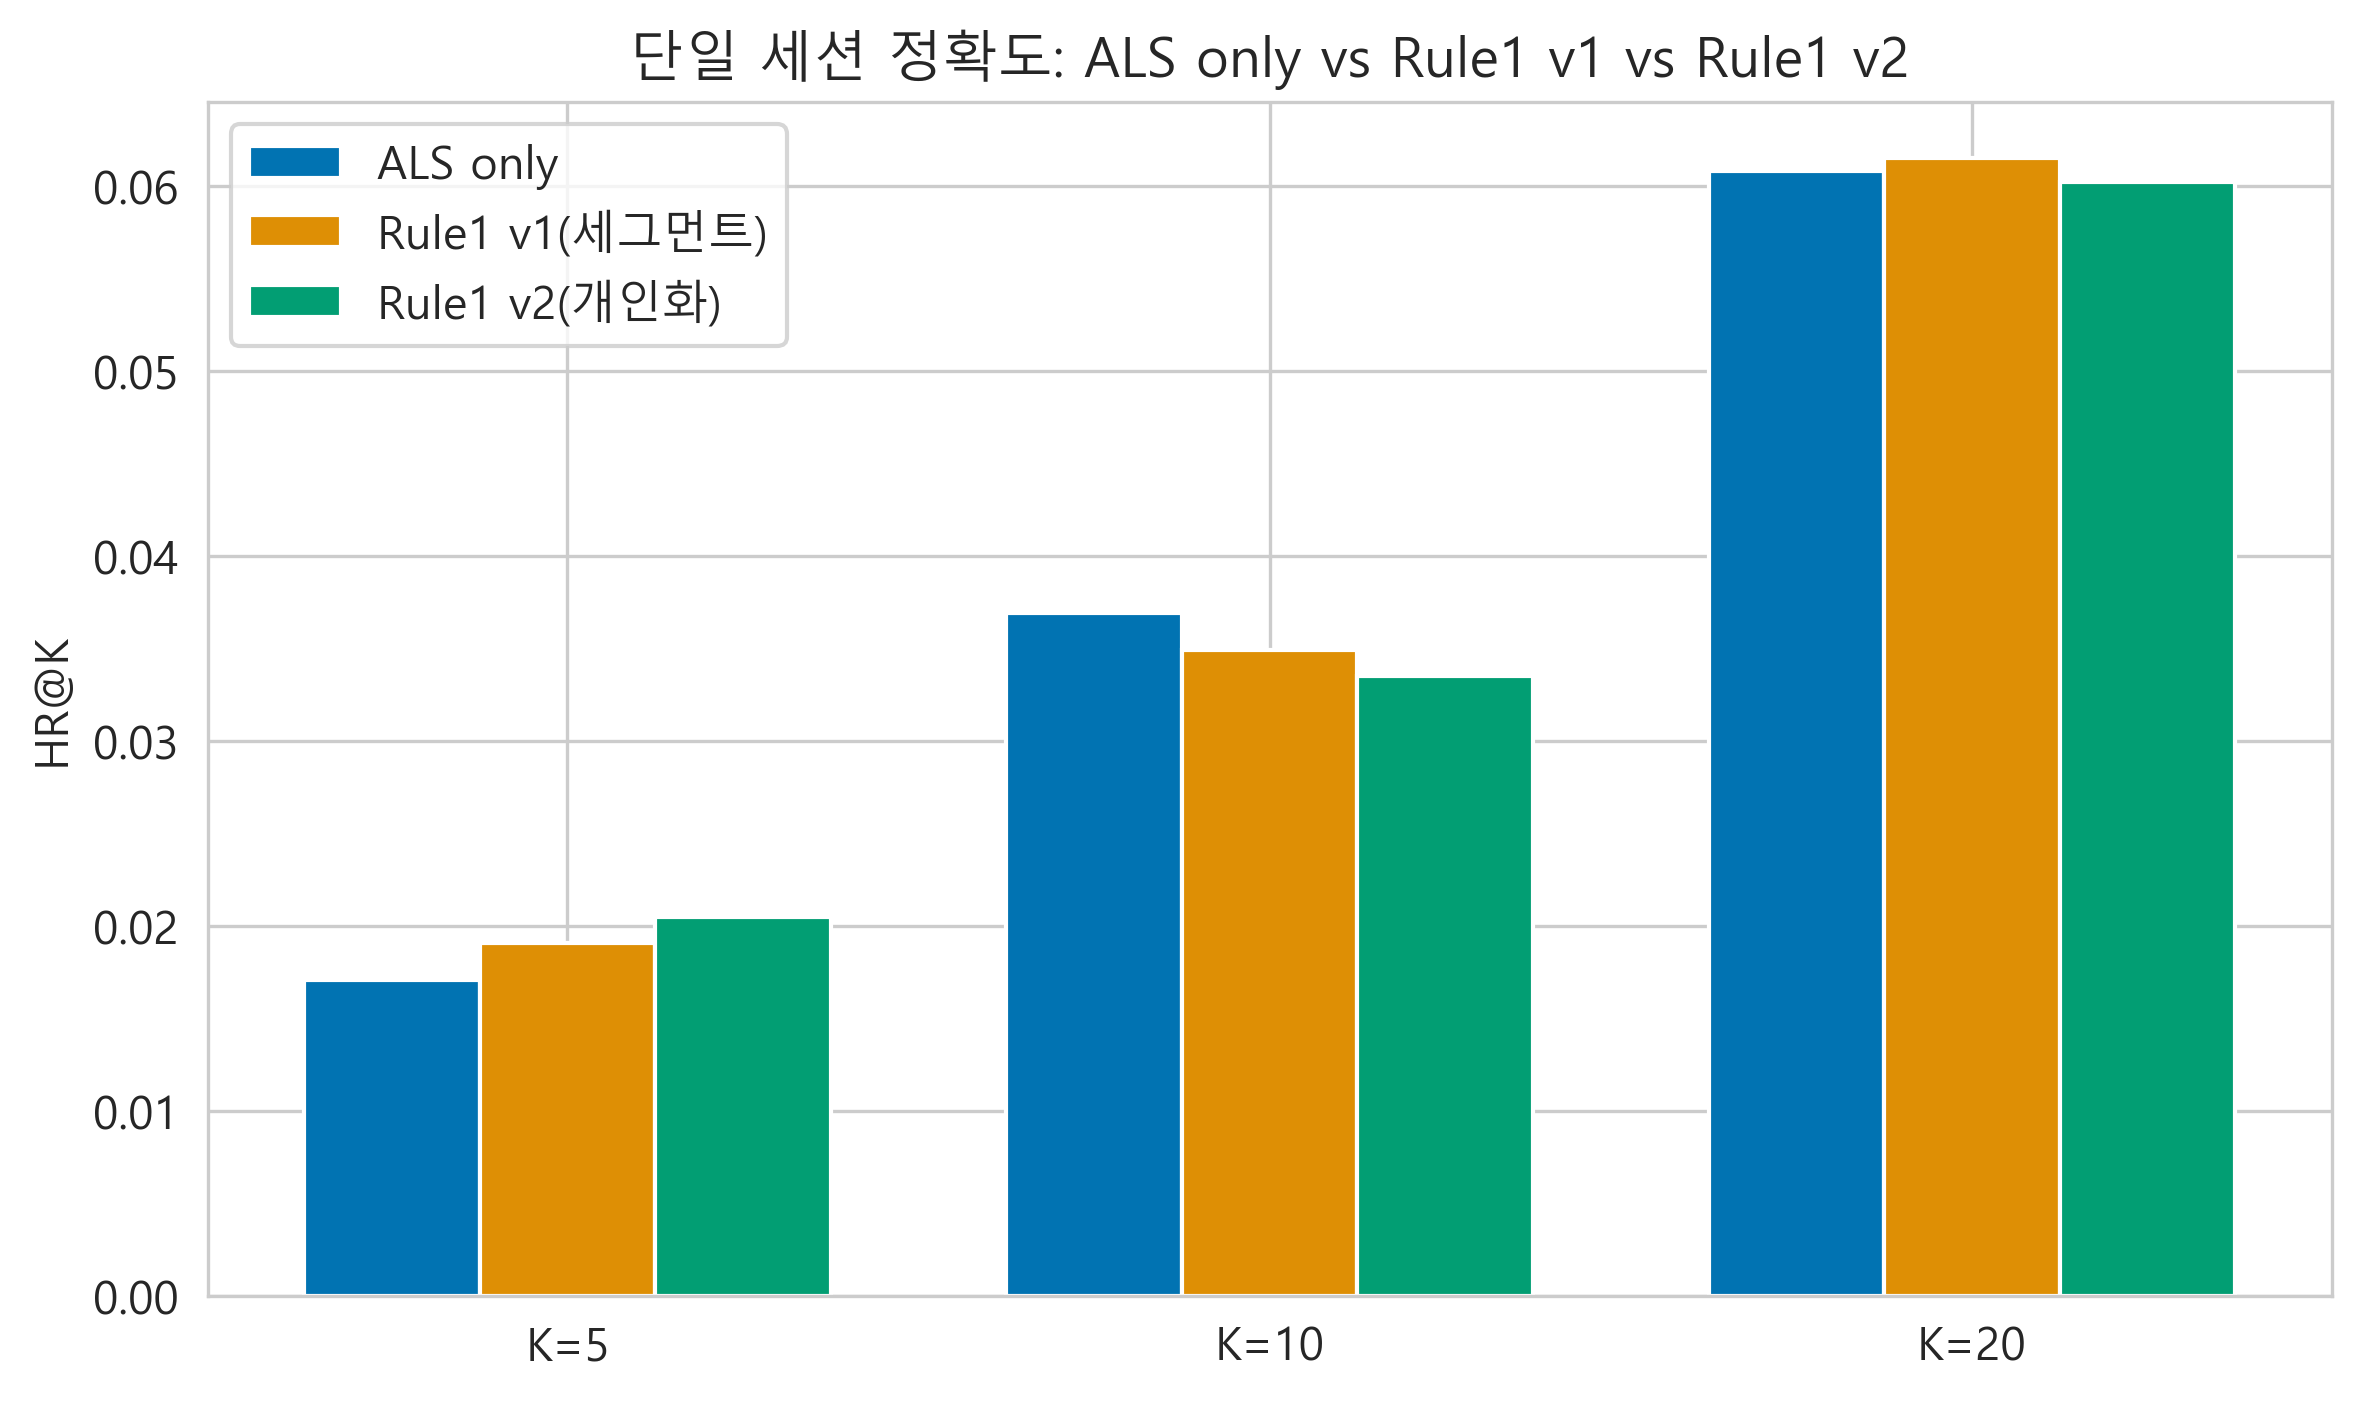

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.8))
x = np.arange(len(K_LIST))
width = 0.25
labels = {"als_only": "ALS only", "v1": "Rule1 v1(세그먼트)", "v2": "Rule1 v2(개인화)"}
for i, cond in enumerate(["als_only", "v1", "v2"]):
    vals = baseline_df[baseline_df["rule1"] == cond].sort_values("k")["HR"].values
    ax.bar(x + (i - 1) * width, vals, width, label=labels[cond], color=PALETTE[i])
ax.set_xticks(x)
ax.set_xticklabels([f"K={k}" for k in K_LIST])
ax.set_ylabel("HR@K")
ax.set_title("단일 세션 정확도: ALS only vs Rule1 v1 vs Rule1 v2")
ax.legend()
plt.tight_layout()
plt.show()

## 5. 반복 새로고침(5회) 다양성 — Rule1 x Rule2 2x2

In [7]:
def simulate_user_sessions_v2(candidates_base, uid, k, rule1_version, rule2_version):
    exposure_counts = {}
    sessions = []
    affinity, alpha = get_rule1_params(uid, rule1_version)
    decay = get_rule2_decay(uid, rule2_version)
    for _ in range(T_SESSIONS):
        candidates = [dict(it) for it in candidates_base]
        exposure_arg = exposure_counts if exposure_counts else None
        reranked = rerank_generic(candidates, id_key="item_id", affinity=affinity, alpha=alpha,
                                   exposure_counts=exposure_arg, decay=decay, top_k=k)
        slate = [it["item_id"] for it in reranked]
        sessions.append(slate)
        decay_and_record_generic(exposure_counts, slate, decay)
    return sessions


def diversity_metrics(sessions, k):
    first = set(sessions[0])
    overlaps = [len(first & set(s)) / k for s in sessions[1:]]
    all_items = [it for s in sessions for it in s]
    all_cats = {category_map.get(it) for it in all_items} - {None}
    first_cats = {category_map.get(it) for it in sessions[0]} - {None}
    return {"repetition_rate": np.mean(overlaps) if overlaps else 1.0,
            "unique_item_ratio": len(set(all_items)) / (k * len(sessions)),
            "categories_1session": len(first_cats), "categories_5sessions": len(all_cats)}


diversity_rows = []
for k in K_LIST:
    pool_n = k * POOL_MULTIPLIER
    for r1 in ["v1", "v2"]:
        for r2 in ["v1", "v2"]:
            acc = {"repetition_rate": [], "unique_item_ratio": [], "categories_1session": [], "categories_5sessions": []}
            for uid in eval_users:
                if uid not in recs_by_user:
                    continue
                candidates_base = recs_by_user[uid][:pool_n]
                sessions = simulate_user_sessions_v2(candidates_base, uid, k, r1, r2)
                m = diversity_metrics(sessions, k)
                for key in acc:
                    acc[key].append(m[key])
            diversity_rows.append({
                "k": k, "rule1": r1, "rule2": r2,
                "repetition_rate": round(np.mean(acc["repetition_rate"]), 4),
                "unique_item_ratio": round(np.mean(acc["unique_item_ratio"]), 4),
                "categories_1session": round(np.mean(acc["categories_1session"]), 2),
                "categories_5sessions": round(np.mean(acc["categories_5sessions"]), 2),
                "n_users": len(acc["repetition_rate"]),
            })
diversity_df = pd.DataFrame(diversity_rows)
print(diversity_df.to_string(index=False))

 k rule1 rule2  repetition_rate  unique_item_ratio  categories_1session  categories_5sessions  n_users
 5    v1    v1           0.3539             0.5879                 2.13                  3.69     1463
 5    v1    v2           0.3691             0.5761                 2.13                  3.64     1463
 5    v2    v1           0.4048             0.5407                 1.83                  3.14     1463
 5    v2    v2           0.4141             0.5345                 1.83                  3.11     1463
10    v1    v1           0.3942             0.5702                 2.93                  4.74     1463
10    v1    v2           0.4140             0.5574                 2.93                  4.66     1463
10    v2    v1           0.4513             0.5189                 2.43                  4.01     1463
10    v2    v2           0.4623             0.5139                 2.43                  3.97     1463
20    v1    v1           0.4493             0.5319                 3.97  

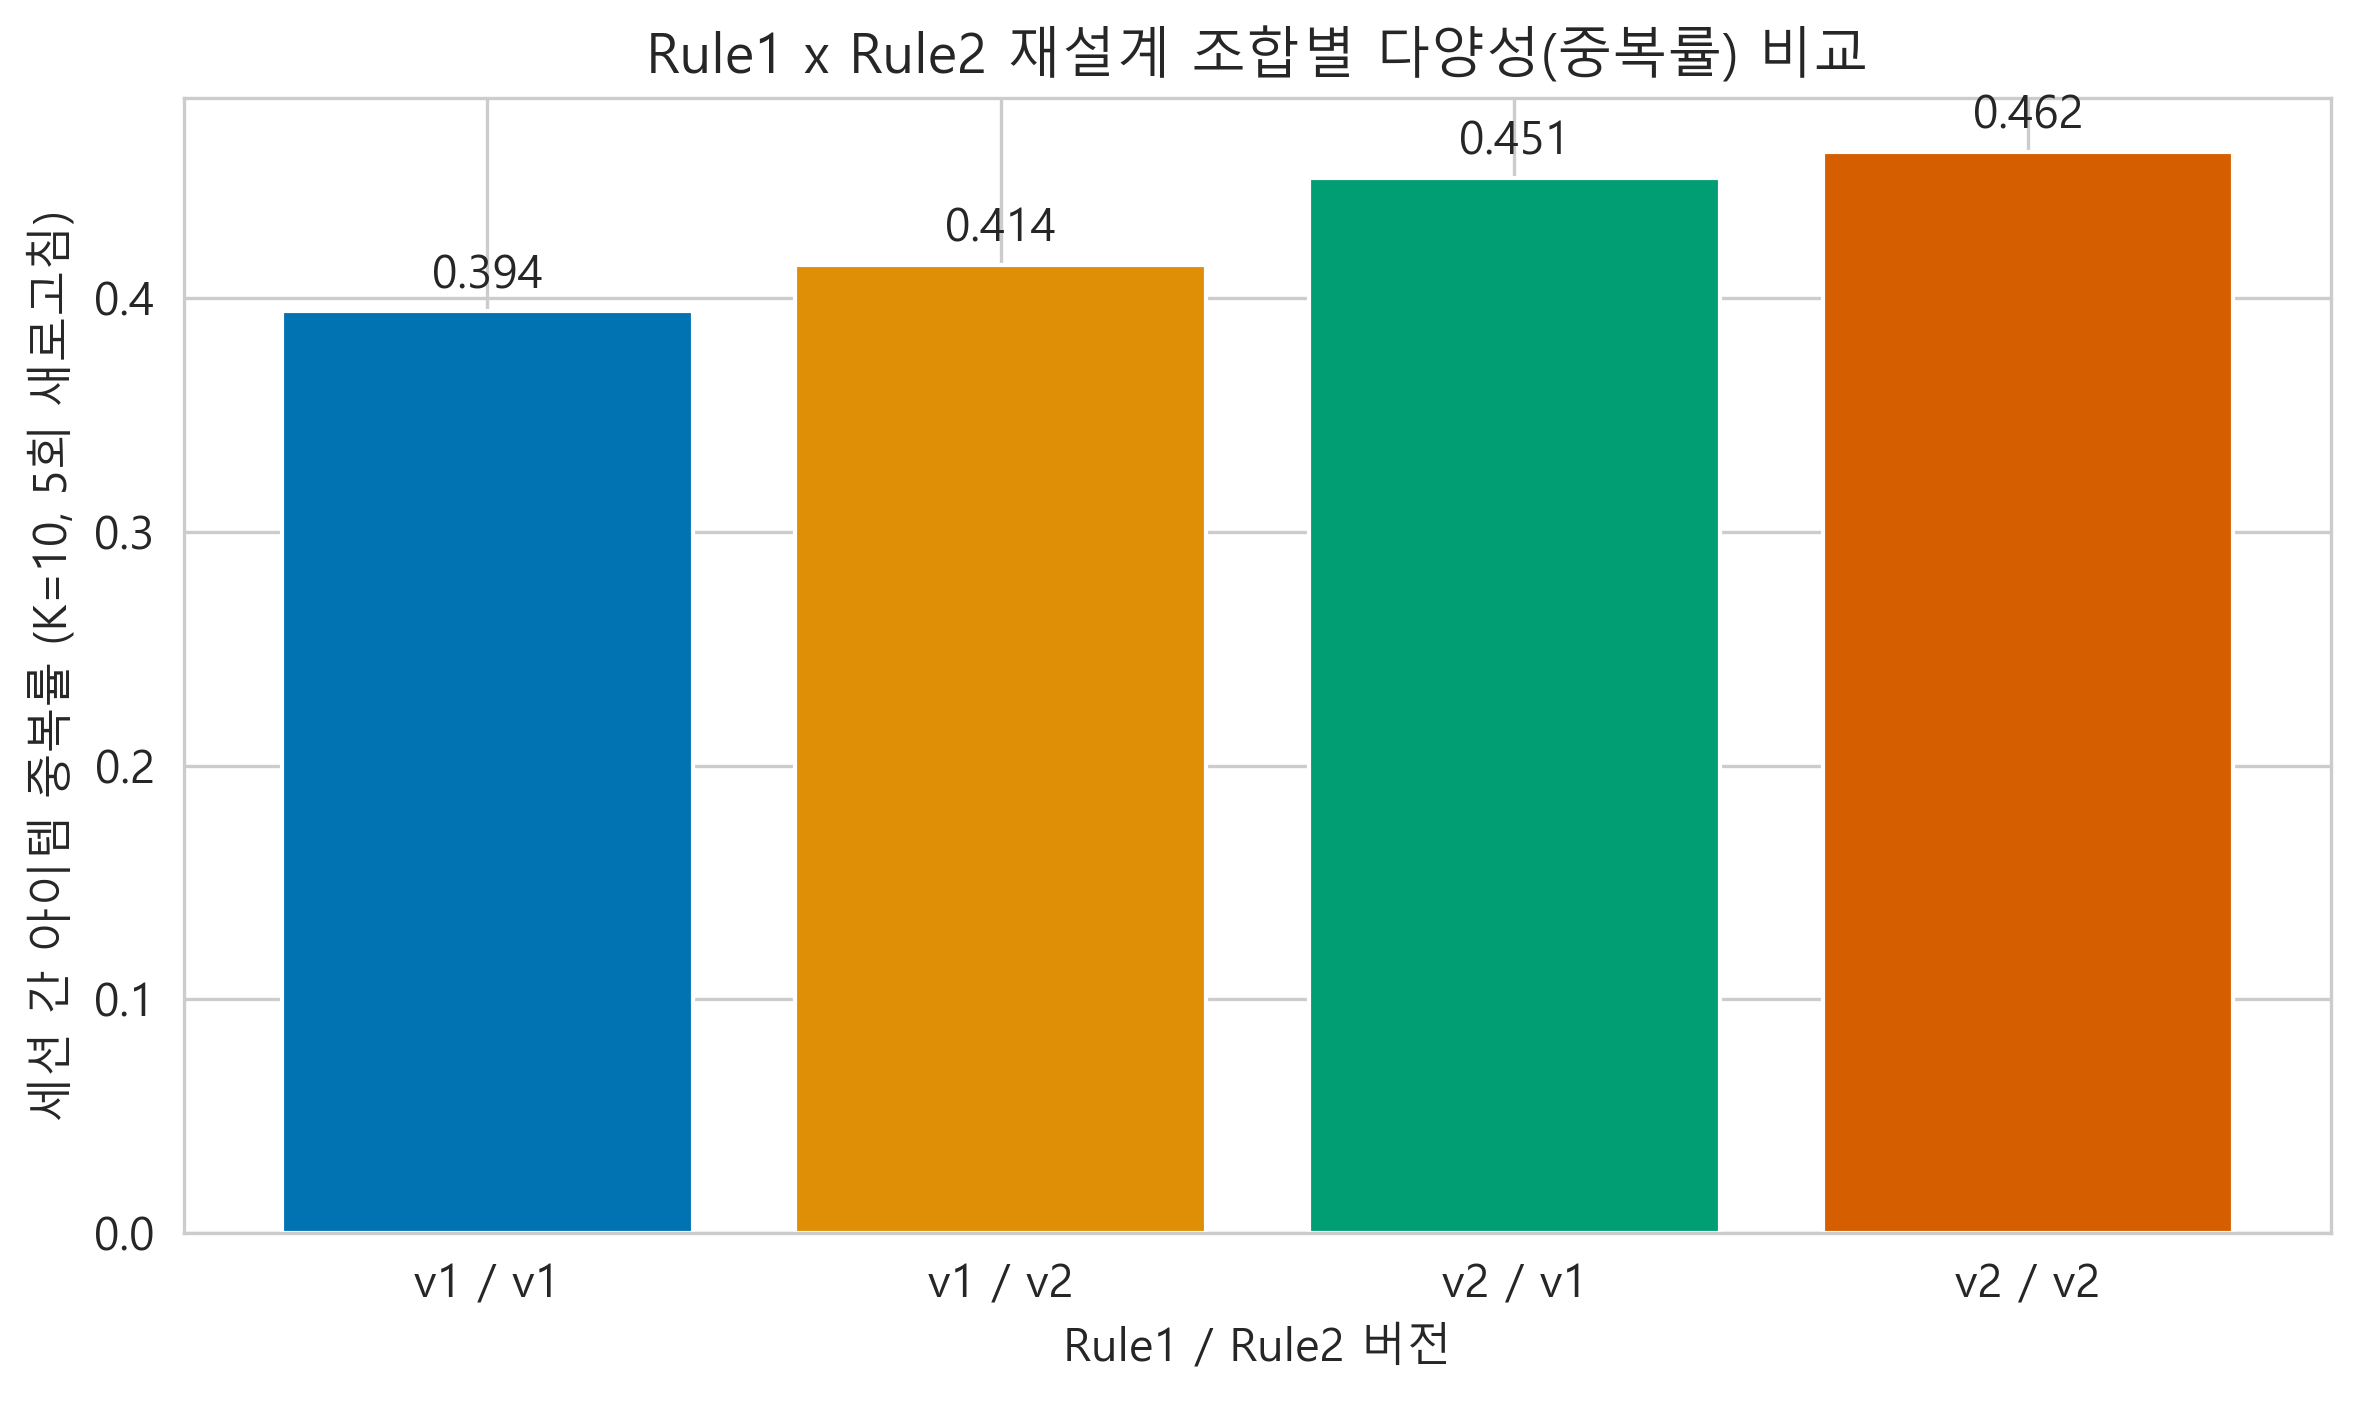

In [8]:
fig2, ax2 = plt.subplots(figsize=(8, 4.8))
sub2 = diversity_df[diversity_df["k"] == 10].copy()
sub2["label"] = sub2["rule1"] + " / " + sub2["rule2"]
ax2.bar(sub2["label"], sub2["repetition_rate"], color=PALETTE[:4])
ax2.set_ylabel("세션 간 아이템 중복률 (K=10, 5회 새로고침)")
ax2.set_xlabel("Rule1 / Rule2 버전")
ax2.set_title("Rule1 x Rule2 재설계 조합별 다양성(중복률) 비교")
for i, v in enumerate(sub2["repetition_rate"]):
    ax2.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

**예상과 다른 지점**: Rule1 v2, Rule2 v2 둘 다 단독으로도, 결합해도 반복률이 기존(v1/v1=0.394)보다 **오히려 높다**(최대 0.462). 개인화·페르소나 연동이 반드시 다양성을 높이는 방향으로 작동하지 않는다는 뜻이라 원인을 진단한다.

## 6. 진단 — 왜 재설계가 다양성을 오히려 낮췄는가

In [9]:
decay_v2_all = DECAY_MAX - (DECAY_MAX - DECAY_MIN) * persona_feat["exploration_tendency"]
q = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
diag_df = pd.DataFrame({
    "quantile": q,
    "exploration_tendency": persona_feat["exploration_tendency"].quantile(q).values,
    "decay_v2": decay_v2_all.quantile(q).values,
})
print(diag_df.round(3).to_string(index=False))
print(f"\n탐색성향=0인 유저 비율: {(persona_feat['exploration_tendency']==0).mean()*100:.1f}% "
      f"→ 이 그룹은 decay_v2=0.85(고정값 0.7보다 훨씬 느린 감쇠)를 받는다.")
print(f"5세션 누적 잔여 배율 비교: 0.85^4={0.85**4:.3f} vs 0.7^4={0.7**4:.3f} vs 0.5^4={0.5**4:.3f}")

 quantile  exploration_tendency  decay_v2
     0.00                 0.000     0.500
     0.10                 0.000     0.588
     0.25                 0.167     0.617
     0.50                 0.544     0.660
     0.75                 0.667     0.792
     0.90                 0.750     0.850
     1.00                 1.000     0.850

탐색성향=0인 유저 비율: 10.4% → 이 그룹은 decay_v2=0.85(고정값 0.7보다 훨씬 느린 감쇠)를 받는다.
5세션 누적 잔여 배율 비교: 0.85^4=0.522 vs 0.7^4=0.240 vs 0.5^4=0.062

**Rule 2 v2가 역효과를 낸 이유**: `exploration_tendency` 분포가 왼쪽으로 치우쳐 있어(중앙값 0.544지만 하위 25%가 0.167 이하), 상당수 유저가 decay_v2 상한(0.85)에 가깝게 몰린다. 지수 함수라 0.85 vs 0.7의 차이는 세션이 반복될수록(4회차 기준 0.522 vs 0.240) 급격히 벌어져, "저탐색 유저의 반복 증가"가 "고탐색 유저의 반복 감소"보다 훨씬 크게 작용한다. → **DECAY_MAX=0.85가 너무 관대하게 설정된 것이 원인**이며, 알고리즘 설계 방향 자체가 틀린 게 아니라 범위 보정이 필요하다는 뜻이다.

**Rule 1 v2가 역효과를 낸 이유**는 아래 세그먼트 사례로 확인한다.

In [10]:
merged = persona_feat.merge(seg[["customer_id", "segment_name"]], left_index=True, right_on="customer_id")
merged["alpha_v2"] = BASE_ALPHA * merged["category_loyalty"] * (1 - merged["exploration_tendency"])
sample_seg_name = "High-Engagement Repeat Purchasers"
sample = merged[merged["segment_name"] == sample_seg_name].copy()
segment_alpha_v1 = persona_service.get_segment_alpha(sample_seg_name)
print(f"'{sample_seg_name}' 세그먼트(n={len(sample):,}) 내 alpha 개인차")
print(f"  세그먼트 평균 alpha(v1, 전원 동일): {segment_alpha_v1:.4f}")
print(f"  개인화 alpha(v2) 분포: mean={sample['alpha_v2'].mean():.4f}, std={sample['alpha_v2'].std():.4f}, "
      f"min={sample['alpha_v2'].min():.4f}, max={sample['alpha_v2'].max():.4f}")

'High-Engagement Repeat Purchasers' 세그먼트(n=4,075) 내 alpha 개인차
  세그먼트 평균 alpha(v1, 전원 동일): 0.6998
  개인화 alpha(v2) 분포: mean=0.3072, std=0.2225, min=0.0000, max=1.5000

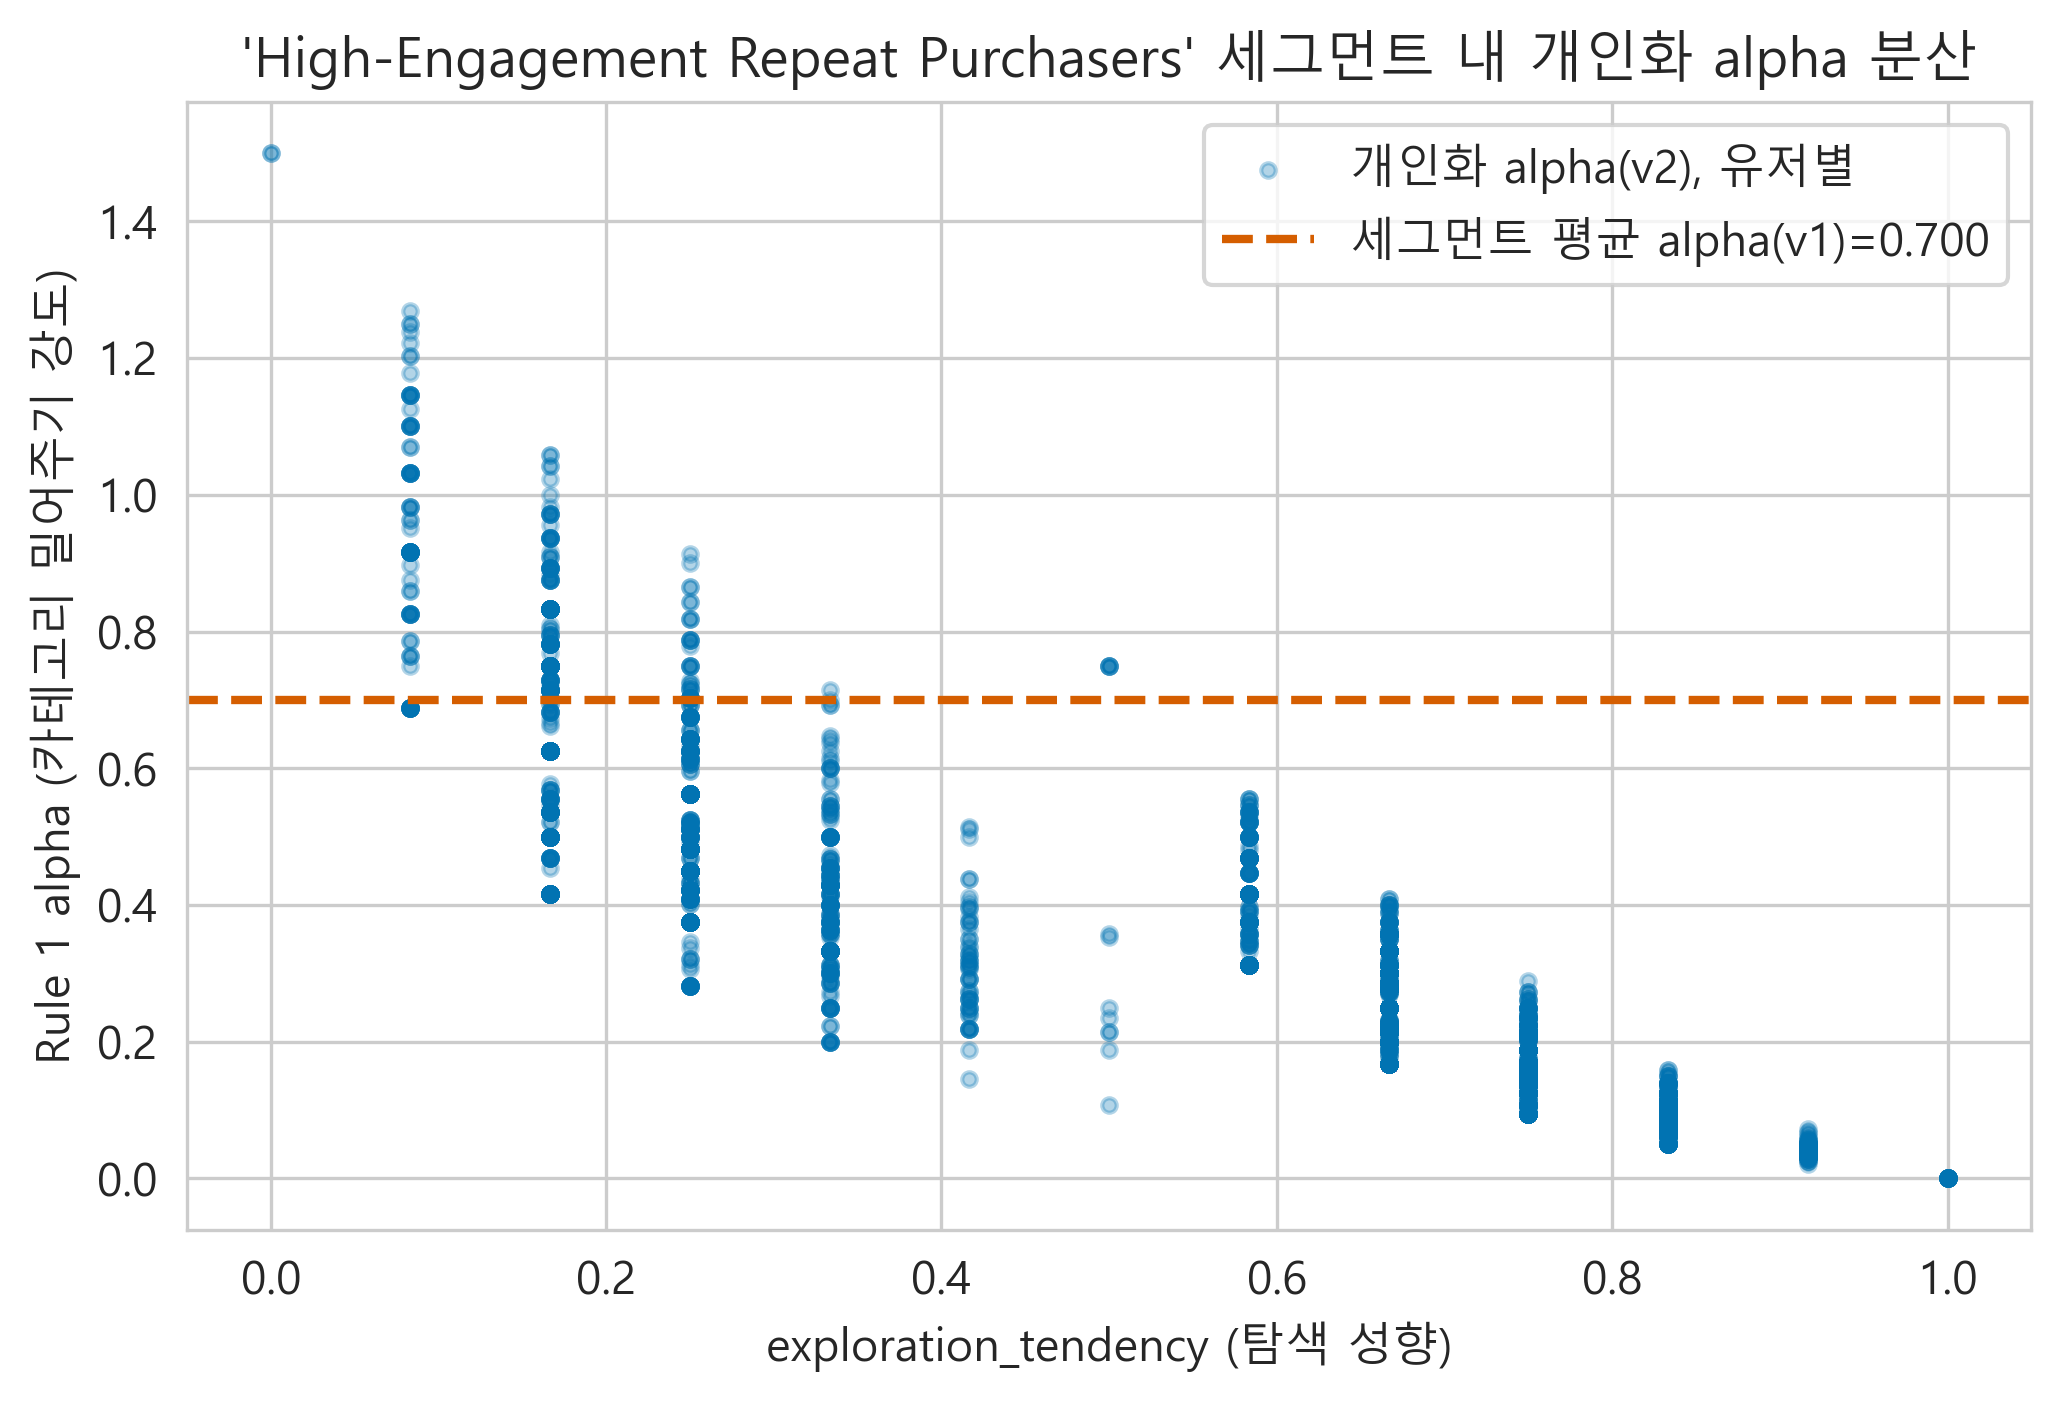

In [11]:
fig3, ax3 = plt.subplots(figsize=(7, 4.8))
ax3.scatter(sample["exploration_tendency"], sample["alpha_v2"], alpha=0.3, s=12, color=PALETTE[0], label="개인화 alpha(v2), 유저별")
ax3.axhline(segment_alpha_v1, color=PALETTE[3], linestyle="--", linewidth=2, label=f"세그먼트 평균 alpha(v1)={segment_alpha_v1:.3f}")
ax3.set_xlabel("exploration_tendency (탐색 성향)")
ax3.set_ylabel("Rule 1 alpha (카테고리 밀어주기 강도)")
ax3.set_title(f"'{sample_seg_name}' 세그먼트 내 개인화 alpha 분산")
ax3.legend()
plt.tight_layout()
plt.show()

세그먼트 평균(v1=0.700)은 모든 유저에게 동일하게 적용됐지만, 개인화(v2)는 **0에서 1.5까지 폭넓게 흩어진다**(표준편차 0.222). 탐색성향이 낮은 유저(그래프 왼쪽)는 alpha가 최대 1.5까지 치솟는 반면, `MULTIPLIER_FLOOR=0.3`은 배율의 **하한만** 막아줄 뿐 **상한은 없다** — 그래서 개인화가 일부 유저에게는 세그먼트 평균보다 훨씬 강한 카테고리 고정(필터버블 위험)을 만든다. 이게 Rule1 v2가 집계 다양성 지표를 오히려 낮춘 핵심 원인이다.

## 결과 요약

**핵심 발견**
1. **Rule 1 v2(유저 개인화)**: K=5에서는 정확도가 개선된다(HR 0.0191→0.0205, NDCG 0.0076→0.0083). 하지만 K=10/20에서는 v1과 유사하거나 소폭 더 나쁘고, 다양성(중복률)은 세 K 전 구간에서 v1보다 나빠진다(K=10 기준 0.394→0.451). 원인은 alpha 배율에 **상한이 없어서**(`MULTIPLIER_FLOOR`는 하한만 존재) 개인화가 일부 유저를 세그먼트 평균보다 더 강하게 한 카테고리에 가둔다.
2. **Rule 2 v2(페르소나 연동 감쇠)**: 의도(탐색형은 빨리 잊고 다양성 확보)와 반대로, 집계 다양성이 오히려 나빠진다(K=10, v1/v1=0.394 → v1/v2=0.414). `exploration_tendency` 분포가 하위 25%에 몰려 있고, `DECAY_MAX=0.85`가 지수함수 특성상 반복될수록 기존 고정값(0.7)보다 훨씬 느리게 잊어 저탐색 유저 집단의 반복 증가가 고탐색 유저 집단의 반복 감소를 압도한다.
3. **Rule 1 v2 + Rule 2 v2를 함께 적용하면 다양성이 가장 나쁘다**(K=10 기준 0.462, 4가지 조합 중 최악) — 두 재설계의 부작용이 누적된다.
4. **Rule 3**: 이번 재설계에서도 재확인 결과 배제가 맞다 — 유저 페르소나·탐색비용 문제와 무관한 아이템 공급측 형평성 장치이며, 세 연구질문 어디에도 해당하지 않는다.

**수치 요약 (K=10, 5회 새로고침)**

| 조합 | HR@10 (단일세션) | 세션 간 중복률 |
|---|---:|---:|
| ALS only | 0.0369 | (Twiddler 미적용, 항상 100%) |
| Rule1 v1 + Rule2 v1 (기존) | 0.0349 | 0.394 |
| Rule1 v2 + Rule2 v1 | 0.0335 | 0.451 |
| Rule1 v1 + Rule2 v2 | 0.0349 | 0.414 |
| Rule1 v2 + Rule2 v2 (전체 재설계) | 0.0335 | 0.462 |

**해석**: "개인화하면 좋아진다"는 직관과 달리, 이번 재설계는 **의도한 방향(다양성 확보)과 반대로 작동**했다. 원인은 아이디어 자체(유저 단위 탐색성향 반영)가 아니라 **파라미터 범위 설정**에 있다 — alpha에 상한이 없고, decay 범위(0.5~0.85)가 분포 왼쪽 쏠림을 고려하지 않고 대칭으로 설계됐다. 즉 연구질문 2("가치관/탐색맥락 반영")의 방향성은 유효하지만, 지금 파라미터로는 오히려 연구질문 3("탐색비용 감소·디깅 경험")에 역행한다.

**한계**
- alpha 상한, decay 범위 모두 임의로 설정한 값이며 그리드서치 등으로 튜닝되지 않았다.
- exploration_tendency는 `category_diversity_purchase`/`view_purchase_category_match`/`dominant_view_category_ratio`만으로 구성한 근사치다 — 가격 민감도, 브랜드 충성도 등 다른 가치관 축은 반영하지 못했다(데이터에 해당 필드가 없음).
- 정확도(HR/Recall/NDCG)는 여전히 "구매를 맞췄는가"만 재는 지표라 연구질문 1(해석가능성)·2(가치관 반영)를 직접 검증하지 못한다 — 이번 비교는 질문 3(탐색비용/다양성)에어 대한 정량 근거를 제공하는 데 집중했다.

**권장 다음 단계**
1. Rule 1 v2의 alpha에 상한을 두고(예: `min(1.0, alpha_effective)`) 다시 비교 — 필터버블 위험 완화 여부 확인
2. Rule 2 v2의 decay 범위를 `exploration_tendency` 분포에 맞춰 비대칭으로 재설계(예: 0.6~0.8처럼 좁히거나, 분포 왼쪽 쏠림을 감안한 non-linear 매핑)하고 재검증
3. 두 가지 모두 재튜닝 후에도 "가치관 기반 개인화가 세그먼트 평균보다 실제로 나은가"를 재확인 — 지금 결과만 보면 **세그먼트 평균(v1)이 다양성 측면에서는 더 안전한 선택**이었다는 점을 발표/포스터에 정직하게 반영하는 것을 추천한다.
